In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [395]:
def describe_df(df):
    descriptive_summary = df.describe(include="all").T
    descriptive_summary["n_unique"] = df.nunique()
    descriptive_summary["null_count"] = df.isnull().sum()
    descriptive_summary["skewness"] = df.skew(numeric_only=True)
    descriptive_summary["kurtosis"] = df.kurtosis(numeric_only=True)
    descriptive_summary["type"] = df.dtypes
    
    try:
        descriptive_summary = descriptive_summary.drop(columns=["unique", "top", "freq"])
    except:
        pass

    return descriptive_summary

In [396]:
insurance_df = pd.read_csv("insurance.csv")
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [397]:
descriptive_summary = describe_df(insurance_df)
descriptive_summary

,count,mean,std,min,25%,50%,75%,max,n_unique,null_count,skewness,kurtosis,type
age,1338.0,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0,47,0,0.055673,-1.245088,int64
sex,1338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,NaN,NaN,object
bmi,1338.0,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13,548,0,0.284047,-0.050732,float64
children,1338.0,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0,6,0,0.938380,0.202454,int64
smoker,1338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,NaN,NaN,object
region,1338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0,NaN,NaN,object
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801,1337,0,1.515880,1.606299,float64


In [398]:
insurance_df = insurance_df.dropna()
insurance_df = insurance_df.drop_duplicates()

insurance_df["smoker"] = insurance_df["smoker"].map({'yes': 1, 'no': 0})
insurance_df["sex"] = insurance_df["sex"].map({'male': 1, 'female': 0})
insurance_df = pd.get_dummies(insurance_df, columns=["region"], drop_first=True, dtype="int64")
insurance_df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [399]:
descriptive_summary = describe_df(insurance_df)
descriptive_summary

,count,mean,std,min,25%,50%,75%,max,n_unique,null_count,skewness,kurtosis,type
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000,47,0,0.054781,-1.244406,int64
sex,1337.0,0.504862,0.500163,0.0000,0.000,1.0000,1.00000,1.00000,2,0,-0.019469,-2.002619,int64
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000,548,0,0.283914,-0.052947,float64
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000,6,0,0.937421,0.200954,int64
smoker,1337.0,0.204936,0.403806,0.0000,0.000,0.0000,0.00000,1.00000,2,0,1.463601,0.142339,int64
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801,1337,0,1.515391,1.604221,float64
region_northwest,1337.0,0.242334,0.428655,0.0000,0.000,0.0000,0.00000,1.00000,2,0,1.204009,-0.551190,int64
region_southeast,1337.0,0.272251,0.445285,0.0000,0.000,0.0000,1.00000,1.00000,2,0,1.024467,-0.951894,int64
region_southwest,1337.0,0.243082,0.429104,0.0000,0.000,0.0000,0.00000,1.00000,2,0,1.199258,-0.562625,int64


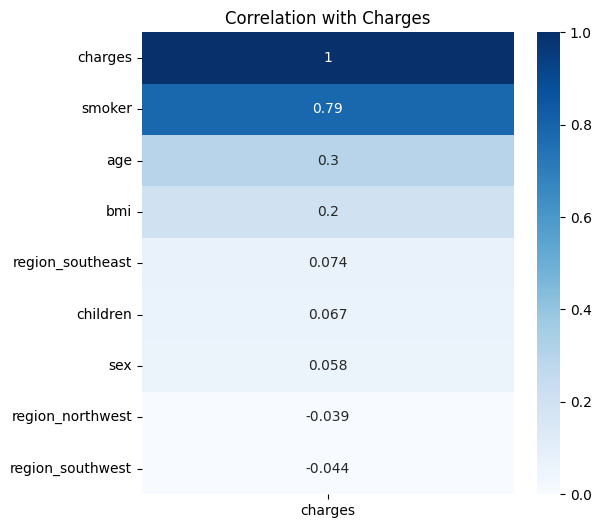

In [400]:
plt.figure(figsize=(6, 6))
charges_corr = insurance_df.corr(numeric_only=True)["charges"].sort_values(ascending=False)
sns.heatmap(charges_corr.to_frame(), annot=True, vmin=0, vmax=1, cmap="Blues")
plt.title(f"Correlation with Charges")
plt.show()


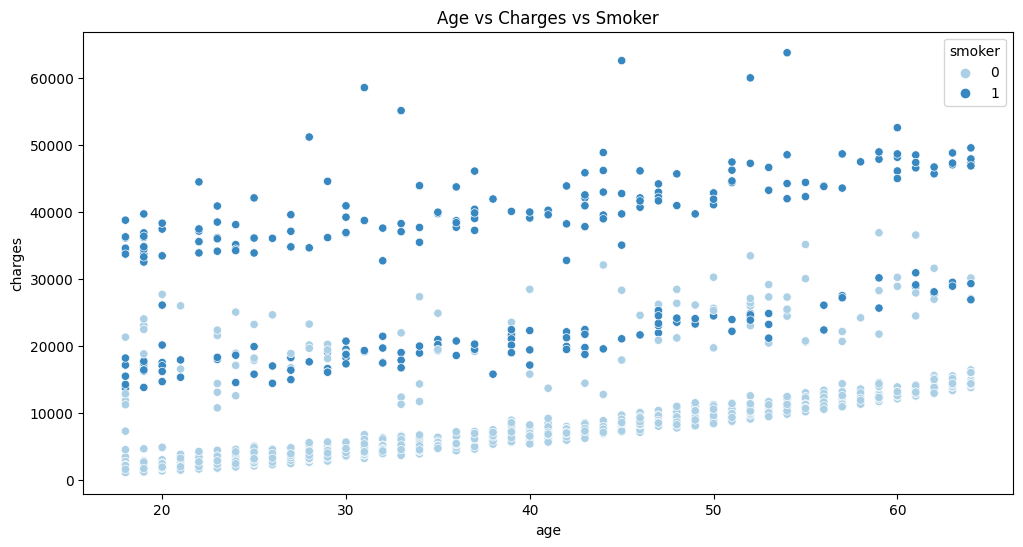

In [401]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='age', y='charges', data=insurance_df, hue='smoker', palette='Blues')
plt.title("Age vs Charges vs Smoker")
plt.show()

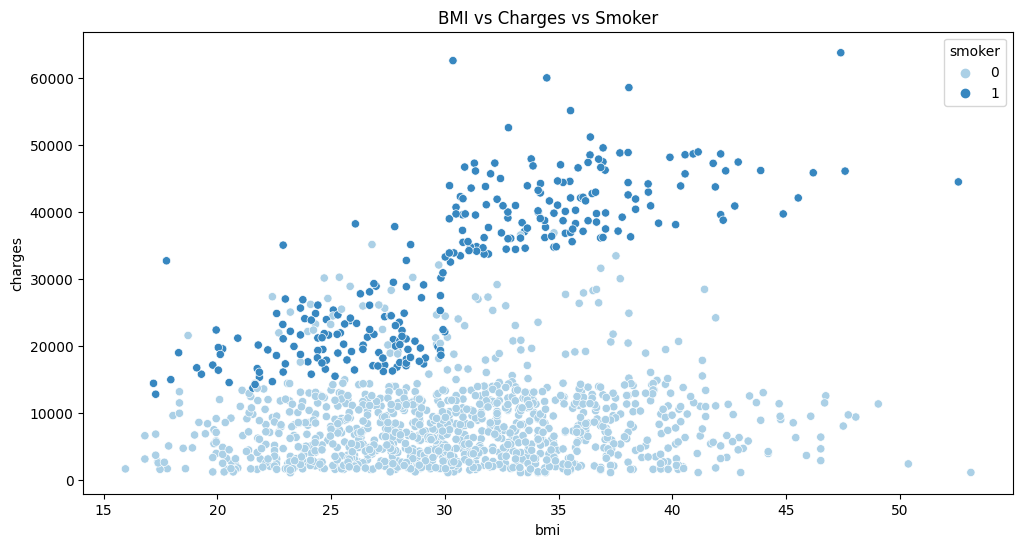

In [402]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='bmi', y='charges', data=insurance_df, hue='smoker', palette='Blues')
plt.title("BMI vs Charges vs Smoker")
plt.show()

In [403]:
X = insurance_df.drop(columns="charges")
y = insurance_df["charges"]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print(f"Lasso R-squared: {lasso.score(X_test_scaled, y_test):.4f}")

Lasso R-squared: 0.8842


In [404]:
insurance_df["predictions"] = lasso.predict(scaler.transform(X_poly))
insurance_df.head(20)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,predictions
0,19,0,27.900,0,1,16884.92400,0,0,1,24052.371362
1,18,1,33.770,1,0,1725.55230,0,1,0,1895.590196
2,28,1,33.000,3,0,4449.46200,0,1,0,5719.850918
3,33,1,22.705,0,0,21984.47061,1,0,0,5926.215929
4,32,1,28.880,0,0,3866.85520,1,0,0,5927.619047
5,31,0,25.740,0,0,3756.62160,0,1,0,5986.098039
6,46,0,33.440,1,0,8240.58960,0,1,0,10364.048189
7,37,0,27.740,3,0,7281.50560,1,0,0,10026.813995
8,37,1,29.830,2,0,6406.41070,0,0,0,8528.123447
9,60,0,25.840,0,0,28923.13692,1,0,0,12629.031584


In [427]:
(
    pd.Series(lasso.coef_, index=feature_names)
    .to_frame('coeficiente')
    .assign(abs_coef=lambda x: x['coeficiente'].abs())
    .sort_values('abs_coef', ascending=False)
    .drop(columns='abs_coef')
    .round()
)

,coeficiente
bmi smoker,17820.0
smoker,-7712.0
age,2815.0
bmi region_southeast,-1728.0
age region_southeast,746.0
age bmi,694.0
region_southeast,625.0
bmi children,601.0
region_southwest,-560.0
age region_southwest,416.0


In [405]:
explainer = shap.LinearExplainer(lasso, X_train_scaled, feature_perturbation="interventional")

c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


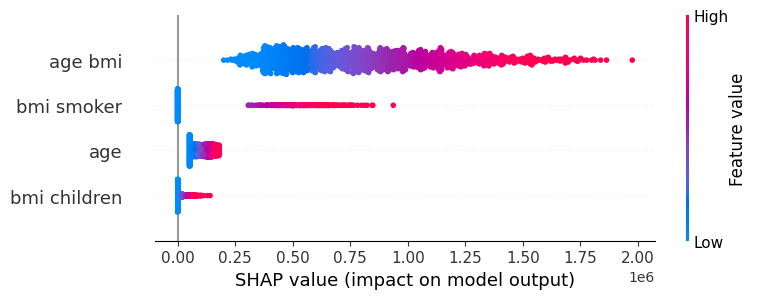

<Figure size 640x480 with 0 Axes>

In [432]:
shap_values = explainer.shap_values(X_poly)

shap.summary_plot(shap_values, X_poly, feature_names=feature_names, max_display=4)
plt.tight_layout()
plt.show()

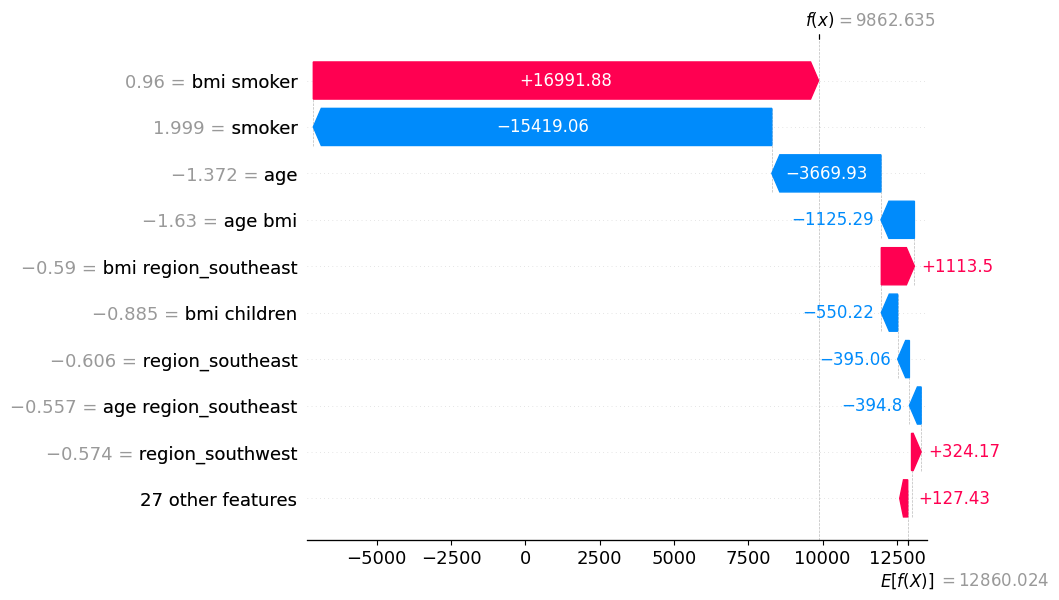

Estimated Insurance Charge: $9,862.63


In [419]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region_nw, region_se, region_sw):
    person = pd.DataFrame([[age, sex, bmi, children, smoker, region_nw, region_se, region_sw]], 
                          columns=['age', 'sex', 'bmi', 'children', 'smoker', 
                                   'region_northwest', 'region_southeast', 'region_southwest'])
    
    person_poly = poly.transform(person) 
    person_scaled = scaler.transform(person_poly)
    
    prediction = lasso.predict(person_scaled)

    shap_values = explainer(person_scaled)

    shap_values.feature_names = list(feature_names)
    shap.plots.waterfall(shap_values[0])
    
    return f"Estimated Insurance Charge: ${prediction[0]:,.2f}"

print(predict_insurance_cost(20, 0, 18.0, 0, 1, 0, 0, 0))
